## Step 2 — CIFAR-10 Loading and Preprocessing

## Import libraries

In [4]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

print("PyTorch version:", torch.__version__)

PyTorch version: 2.13.0+cpu


## Define image preprocessing

In [9]:
transform = transforms.Compose([
    transforms.ToTensor()
])

print("Image preprocessing defined.")

Image preprocessing defined.


## Load the training and test datasets

In [11]:
train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=False,
    transform=transform
)

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Training samples: 50000
Test samples: 10000


## Check one image

In [16]:
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)
print("Pixel minimum:", image.min().item())
print("Pixel maximum:", image.max().item())

Image shape: torch.Size([3, 32, 32])
Label: 6
Pixel minimum: 0.0
Pixel maximum: 1.0


## Check the CIFAR-10 classes

In [19]:
print("Classes:")

for i, class_name in enumerate(train_dataset.classes):
    print(i, ":", class_name)

Classes:
0 : airplane
1 : automobile
2 : bird
3 : cat
4 : deer
5 : dog
6 : frog
7 : horse
8 : ship
9 : truck


## Verify the number of samples per class

In [22]:
from collections import Counter

class_counts = Counter(train_dataset.targets)

print("Training samples per class:")

for class_id, count in sorted(class_counts.items()):
    print(
        class_id,
        train_dataset.classes[class_id],
        ":",
        count
    )

Training samples per class:
0 airplane : 5000
1 automobile : 5000
2 bird : 5000
3 cat : 5000
4 deer : 5000
5 dog : 5000
6 frog : 5000
7 horse : 5000
8 ship : 5000
9 truck : 5000


## Create DataLoaders

In [25]:
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))

Training batches: 391
Testing batches: 79


## Verify one complete batch

In [28]:
images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)
print("Number of images in batch:", images.size(0))

Batch image shape: torch.Size([128, 3, 32, 32])
Batch label shape: torch.Size([128])
Number of images in batch: 128


## Visualize some images

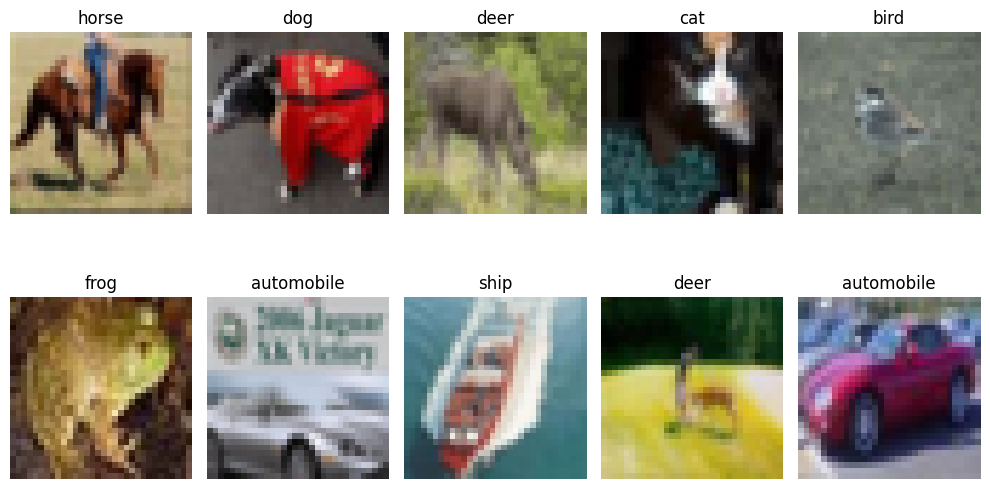

In [33]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].permute(1, 2, 0))
    plt.title(train_dataset.classes[labels[i].item()])
    plt.axis("off")

plt.tight_layout()
plt.show()